<a href="https://colab.research.google.com/github/niradaa-art/Project_252-4/blob/main/Part_1_Nirada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Social Listening Warm-up

## นางสาวณิรดา อนุนิวัฒน์ 673020252-4

## Dataset
https://drive.google.com/drive/folders/1frJWX4tX9OGW7HPWIVWI0wt7xZ6jePef?usp=drive_link

##ตอบ 4 คำถามหลัก
1.คนโพสต์เมื่อไร: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

2.ใช้ภาษาอะไร: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

3.คนพูดถึงอะไร: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

4.ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้: สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json

folder = "/content/drive/MyDrive/part_1"

files = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith(".jsonl")
]

print("จำนวนไฟล์ทั้งหมด:", len(files))
print("\nรายชื่อไฟล์:")

for file in files:
    print("-", os.path.basename(file))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
จำนวนไฟล์ทั้งหมด: 3

รายชื่อไฟล์:
- posts_20241127_120237.jsonl
- posts_20241127_075630.jsonl
- posts_20241127_130559.jsonl


In [ ]:
import os
import json

for file in files:

    print("\n" + "=" * 80)
    print("FILE:", os.path.basename(file))
    print("=" * 80)

    # ขนาดไฟล์
    size_mb = os.path.getsize(file) / (1024 * 1024)
    print(f"File size: {size_mb:.2f} MB")

    # อ่านทีละบรรทัด
    count = 0
    first_rows = []

    with open(file, encoding="utf-8") as f:

        for line in f:

            if line.strip():

                count += 1

                # เก็บ 5 แถวแรกไว้ดู
                if len(first_rows) < 5:
                    first_rows.append(json.loads(line))

    print("Number of records:", count)

    # ดูชื่อ field
    if first_rows:
        print("\nColumns / Fields:")
        print(list(first_rows[0].keys()))

        print("\nFirst 5 records:")

        for i, row in enumerate(first_rows, 1):
            print(f"\n--- Record {i} ---")
            print(json.dumps(
                row,
                ensure_ascii=False,
                indent=2
            ))


FILE: posts_20241127_120237.jsonl
File size: 37.55 MB
Number of records: 100000

Columns / Fields:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']

First 5 records:

--- Record 1 ---
{
  "text": "Same here Tanis! Was a lovely time ❤️",
  "created_at": "2024-11-27T12:02:36.821Z",
  "author": "did:plc:drbw223wpmvnnkpoxjsr36du",
  "uri": "at://did:plc:drbw223wpmvnnkpoxjsr36du/app.bsky.feed.post/3lbwiyxxpkc25",
  "has_images": false,
  "reply_to": "at://did:plc:bywg42wvodfgeccofhlzgy7v/app.bsky.feed.post/3lbq33c4hz224"
}

--- Record 2 ---
{
  "text": "What is this place? #bluesky",
  "created_at": "2024-11-27T12:02:36.987Z",
  "author": "did:plc:dkv6csztjlzhh3hqk7z3asrj",
  "uri": "at://did:plc:dkv6csztjlzhh3hqk7z3asrj/app.bsky.feed.post/3lbwiyy4rnu2o",
  "has_images": false,
  "reply_to": null
}

--- Record 3 ---
{
  "text": "😮‍💨",
  "created_at": "2024-11-27T12:02:37.170Z",
  "author": "did:plc:h3vh4vyfnic4akr47mjtmqli",
  "uri": "at://did:plc:h3vh4vyfnic4akr47mjtmqli/

In [ ]:
import pandas as pd

for file in files:

    print("\n" + "=" * 80)
    print("FILE:", os.path.basename(file))
    print("=" * 80)

    rows = []

    with open(file, encoding="utf-8") as f:

        for line in f:

            if line.strip():

                rows.append(json.loads(line))

                if len(rows) >= 10:
                    break

    df_preview = pd.DataFrame(rows)

    display(df_preview)


FILE: posts_20241127_120237.jsonl


,text,created_at,author,uri,has_images,reply_to
0,Same here Tanis! Was a lovely time ❤️,2024-11-27T12:02:36.821Z,did:plc:drbw223wpmvnnkpoxjsr36du,at://did:plc:drbw223wpmvnnkpoxjsr36du/app.bsky...,False,at://did:plc:bywg42wvodfgeccofhlzgy7v/app.bsky...
1,What is this place? #bluesky,2024-11-27T12:02:36.987Z,did:plc:dkv6csztjlzhh3hqk7z3asrj,at://did:plc:dkv6csztjlzhh3hqk7z3asrj/app.bsky...,False,None
2,😮‍💨,2024-11-27T12:02:37.170Z,did:plc:h3vh4vyfnic4akr47mjtmqli,at://did:plc:h3vh4vyfnic4akr47mjtmqli/app.bsky...,False,None
3,We've picked our favourite sports books for Xm...,2024-11-27T12:02:33.573Z,did:plc:gcusr2pl22sf7nwlwf5msxsa,at://did:plc:gcusr2pl22sf7nwlwf5msxsa/app.bsky...,True,None
4,運良く入場できたらな。入り口の脇に「○○分待ち」の看板が用意してあった,2024-11-27T12:02:36.665Z,did:plc:of4fr4ranpets7xlri2u6b34,at://did:plc:of4fr4ranpets7xlri2u6b34/app.bsky...,False,at://did:plc:isvyr36mxukx6nbnvhoepcpm/app.bsky...
5,간다아\n이거 무엇이애요?,2024-11-27T12:02:35.156Z,did:plc:acw3ztu6xnm2poiwlqduhuol,at://did:plc:acw3ztu6xnm2poiwlqduhuol/app.bsky...,True,at://did:plc:acw3ztu6xnm2poiwlqduhuol/app.bsky...
6,,2024-11-27T12:02:35Z,did:plc:tck2msgzhmylnhapcdzeeo4j,at://did:plc:tck2msgzhmylnhapcdzeeo4j/app.bsky...,False,None
7,빨리 퍼뜨려요 빨리\n탐라에 감기를 대유행시키자,2024-11-27T12:02:36.169Z,did:plc:muxwcw6snd6bfvstrhslcabz,at://did:plc:muxwcw6snd6bfvstrhslcabz/app.bsky...,False,None
8,Por eso casi toda mi familia emigró a Venezuel...,2024-11-27T12:02:36.748Z,did:plc:r2247gh3uiwnz7ozzb3evckp,at://did:plc:r2247gh3uiwnz7ozzb3evckp/app.bsky...,False,None
9,こんばんは🙇🌸,2024-11-27T12:02:36.345Z,did:plc:wyi7yum26ka7dzssle7vpxej,at://did:plc:wyi7yum26ka7dzssle7vpxej/app.bsky...,False,at://did:plc:6do5qghhxdk6oom2mfog7ij7/app.bsky...



FILE: posts_20241127_075630.jsonl


,text,created_at,author,uri,has_images,reply_to
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z,did:plc:z3dbv7bbotsaxzdmmlwoypha,at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky...,False,None
1,Lovely stuff.,2024-11-27T07:56:28.717Z,did:plc:4dn3nlaku6z3ltxzkxglyqdq,at://did:plc:4dn3nlaku6z3ltxzkxglyqdq/app.bsky...,False,at://did:plc:y7vhfdg5iq7qbotunr767enp/app.bsky...
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z,did:plc:fn4xjeryjchlrtjwippuumxm,at://did:plc:fn4xjeryjchlrtjwippuumxm/app.bsky...,True,None
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。,2024-11-27T07:56:28.499Z,did:plc:aaf7jrpncnzlbiqfzkgugowq,at://did:plc:aaf7jrpncnzlbiqfzkgugowq/app.bsky...,False,None
4,WoAH,2024-11-27T07:56:29.868Z,did:plc:l6fvehl7vj44d44aydnds7qr,at://did:plc:l6fvehl7vj44d44aydnds7qr/app.bsky...,False,at://did:plc:54ordrb4cjngwlivuadayono/app.bsky...
5,POV t’es un docteur médiatique et tu vois pass...,2024-11-27T07:56:28.971Z,did:plc:yc6fqrgic2suqfgy4bwiofin,at://did:plc:yc6fqrgic2suqfgy4bwiofin/app.bsky...,True,at://did:plc:q6eipj4yf4zfvzufnfqfdyeq/app.bsky...
6,A weighted blanket made out of little suitcases,2024-11-27T07:56:30.683Z,did:plc:tfnxifpo2m7fh63zfzj5iofc,at://did:plc:tfnxifpo2m7fh63zfzj5iofc/app.bsky...,False,None
7,カース・オブ・労働になってた,2024-11-27T07:56:30.029Z,did:plc:6y2xnrkicuaxdd2jrefppuly,at://did:plc:6y2xnrkicuaxdd2jrefppuly/app.bsky...,False,None
8,When is SXSW ?,2024-11-27T07:56:30.301Z,did:plc:vrmqs7bsgqyn3bh727q7v5cu,at://did:plc:vrmqs7bsgqyn3bh727q7v5cu/app.bsky...,False,None
9,今日あと6時間ある,2024-11-27T07:56:29.743Z,did:plc:v63cze2tdm4xbilelcnadnpd,at://did:plc:v63cze2tdm4xbilelcnadnpd/app.bsky...,False,None



FILE: posts_20241127_130559.jsonl


,text,created_at,author,uri,has_images,reply_to
0,First post on BlueSky Social!,2024-11-27T13:05:55.291Z,did:plc:ozslkehddnlak4oo7soximq3,at://did:plc:ozslkehddnlak4oo7soximq3/app.bsky...,True,None
1,"Explore stunning beaches, ancient cities, deli...",2024-11-27T13:05:56Z,did:plc:nqui4jen3wzych5cwlucbvw7,at://did:plc:nqui4jen3wzych5cwlucbvw7/app.bsky...,False,None
2,툭죽파면서 많은짤을 만들엇지만 저 휑~ 짤이 제일잘만든짤 탑쓰리에 꼽는거같아요,2024-11-27T13:05:57.973Z,did:plc:t2qy5fwrblffouzyk3zg7c2e,at://did:plc:t2qy5fwrblffouzyk3zg7c2e/app.bsky...,False,None
3,I don't know what to think other than that's h...,2024-11-27T13:05:59.728Z,did:plc:uw564jrytdw244lwdrunfjca,at://did:plc:uw564jrytdw244lwdrunfjca/app.bsky...,False,at://did:plc:fnsoxxgnty6tlcqr3csx6tmb/app.bsky...
4,I do see him as an all time great now. He's a ...,2024-11-27T13:05:59.012Z,did:plc:lagbkjizvso3cciwansidpvn,at://did:plc:lagbkjizvso3cciwansidpvn/app.bsky...,False,at://did:plc:ibt2txpx6svolieilaf57dwm/app.bsky...
5,Marmalade Mussolini is already claiming credit...,2024-11-27T13:05:59.087Z,did:plc:fcibwtib4opugqpklkp6el6x,at://did:plc:fcibwtib4opugqpklkp6el6x/app.bsky...,False,at://did:plc:xdtqbgxxdtslrdu7f5pfvuyy/app.bsky...
6,I love this movie so much. The most fun I’ve h...,2024-11-27T13:05:59.139Z,did:plc:oa2bp26xzq6bfjwubumpvjgn,at://did:plc:oa2bp26xzq6bfjwubumpvjgn/app.bsky...,False,at://did:plc:4hhw3phwj75nywfc5pv3ilxm/app.bsky...
7,,2024-11-27T13:05:55.728Z,did:plc:pteyuy7ogwuhh3yaqim6ipt3,at://did:plc:pteyuy7ogwuhh3yaqim6ipt3/app.bsky...,True,None
8,de hecho acabo de ver a una chica vendiendo un...,2024-11-27T13:05:57.366Z,did:plc:bpvbuwndlndlavhdlg7snaw7,at://did:plc:bpvbuwndlndlavhdlg7snaw7/app.bsky...,False,at://did:plc:bpvbuwndlndlavhdlg7snaw7/app.bsky...
9,Dat staat nergens? Er is een pleidooi om migra...,2024-11-27T13:05:58.140Z,did:plc:plkhjetmplrkt7nrdartwabc,at://did:plc:plkhjetmplrkt7nrdartwabc/app.bsky...,False,at://did:plc:qo3qm4b4usktybov5xqgfhrp/app.bsky...


# ตอบคำถาม

#1.คนโพสต์เมื่อไร: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

In [ ]:
import json
from collections import Counter
from datetime import datetime

def iter_jsonl(file_path):
    with open(file_path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

total_posts = 0
min_date = None
max_date = None
hour_counts = Counter()
authors = set()

for file in files:
    for post in iter_jsonl(file):

        total_posts += 1

        # เวลา
        dt = datetime.fromisoformat(
            post["created_at"].replace("Z", "+00:00")
        )

        if min_date is None or dt < min_date:
            min_date = dt

        if max_date is None or dt > max_date:
            max_date = dt

        hour_counts[dt.hour] += 1

        # จำนวน author ไม่ซ้ำ
        authors.add(post["author"])


print("===== POST INFORMATION =====")
print("Total posts:", total_posts)
print("Unique authors:", len(authors))
print("Start:", min_date)
print("End:", max_date)

peak_hour, peak_count = hour_counts.most_common(1)[0]

print(
    "Peak hour:",
    f"{peak_hour:02d}:00 UTC",
    "(",
    peak_count,
    "posts)"
)

===== POST INFORMATION =====
Total posts: 300000
Unique authors: 142189
Start: 2008-04-13 03:08:59+00:00
End: 2024-11-30 10:50:04.343000+00:00
Peak hour: 12:00 UTC ( 94840 posts)


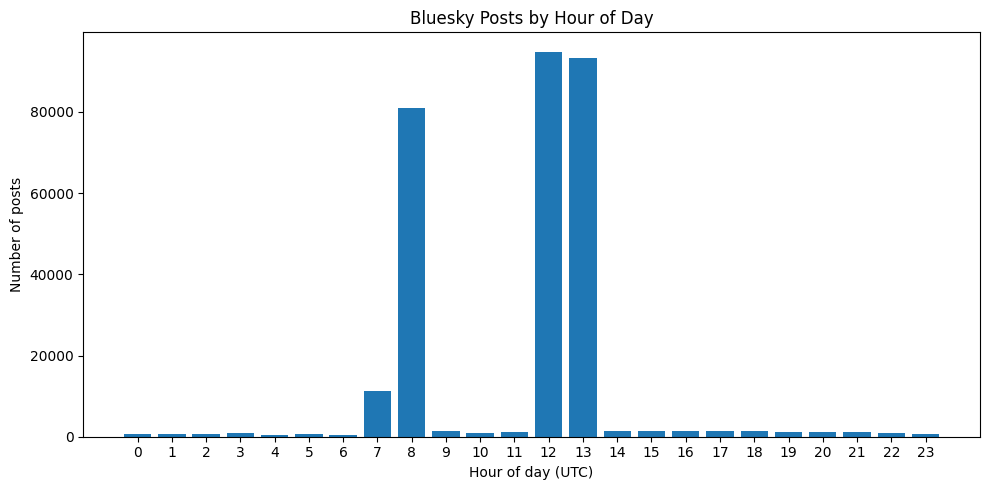

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a Series with all 24 hours and their counts
hourly_posts = pd.Series({
    hour: hour_counts.get(hour, 0)
    for hour in range(24)
}).sort_index()

plt.figure(figsize=(10, 5))

plt.bar(hourly_posts.index, hourly_posts.values)

plt.xlabel("Hour of day (UTC)")
plt.ylabel("Number of posts")
plt.title("Bluesky Posts by Hour of Day")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

## ตอบ คนโพสต์เมื่อไร: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

จากข้อมูลที่นำมาวิเคราะห์ทั้งหมด 300,000 โพสต์ พบว่ามีผู้เขียนที่ไม่ซ้ำกัน 142,189 คน โดยข้อมูลครอบคลุมตั้งแต่วันที่ 13 เมษายน 2008 เวลา 03:08:59 UTC จนถึงวันที่ 30 พฤศจิกายน 2024 เวลา 10:50:04 UTC

เมื่อดูช่วงเวลาที่มีการโพสต์มากที่สุด พบว่า 12:00 UTC มีจำนวนโพสต์สูงสุดถึง 94,840 โพสต์ หรือประมาณ 19:00 น. ตามเวลาไทย แสดงให้เห็นว่าในข้อมูลชุดนี้ ผู้ใช้มีการโพสต์หนาแน่นในช่วงเวลาดังกล่าว

#2.ใช้ภาษาอะไร: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

In [ ]:
import pandas as pd

# Load all posts into a DataFrame
all_posts = []
for file in files:
    for post in iter_jsonl(file):
        all_posts.append(post)

df = pd.DataFrame(all_posts)

# ตรวจสอบข้อมูล text
total_posts = len(df)

missing_text = df["text"].isna().sum()
empty_text = (df["text"].fillna("").str.strip() == "").sum()

print("Total posts:", total_posts)
print("Missing text:", missing_text)
print("Empty text:", empty_text)

# สร้างชุดข้อมูลข้อความที่ไม่ว่าง
text_df = df[
    df["text"].notna() &
    (df["text"].str.strip() != "")
].copy()

print("Usable text posts:", len(text_df))

# ดูตัวอย่างข้อความ
display(text_df[["text"]].head(10))

Total posts: 300000
Missing text: 0
Empty text: 9729
Usable text posts: 290271


,text
0,Same here Tanis! Was a lovely time ❤️
1,What is this place? #bluesky
2,😮‍💨
3,We've picked our favourite sports books for Xm...
4,運良く入場できたらな。入り口の脇に「○○分待ち」の看板が用意してあった
5,간다아\n이거 무엇이애요?
7,빨리 퍼뜨려요 빨리\n탐라에 감기를 대유행시키자
8,Por eso casi toda mi familia emigró a Venezuel...
9,こんばんは🙇🌸
10,I'm with you on succulents and Rammstein (with...


In [ ]:
!pip install langdetect -q

import json
import os
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

from langdetect import detect, DetectorFactory

# ทำให้ผลการตรวจภาษาเหมือนเดิมทุกครั้ง
DetectorFactory.seed = 0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
RANDOM_SEED = 42

# ทดสอบตรวจภาษาจากข้อความตัวอย่าง 50 โพสต์
sample_texts = text_df["text"].sample(
    n=50,
    random_state=RANDOM_SEED
)

for i, text in enumerate(sample_texts, start=1):
    try:
        language = detect(text)
    except:
        language = "unknown"

    print(f"{i}. [{language}] {text[:150]}")

1. [unknown] 😁
2. [ko] 野村不動産ＨＬＤＧＳ(3231)　東証Ｐ
始値3721円　高値3738円　安値3682円　終値3716円　前日比-61円(-1.62%)　ＶＷＡＰ3710.3232円　出来高1,175,400株　前日比279,700株減(-19.22%)
信用倍率10.67倍　売残32100株　買残342400株　
3. [en] "Goodbye, young human. I hope you live."

Just drop a house on her.  

#dune
4. [ja] 無意識のうちに「失敗を怖れてる」気がするなー。
手が遅い原因のひとつかも・・・・。
5. [en] Welcome James, how are you? 💋
6. [fa] آبی میگرفتی😛😛😛
7. [en] Stunning! RT @cristianvasile Jaw-Dropping Urban Photography http://bit.ly/1KN6B0
8. [ja] かわいい…！淡くてきらきらした塗り素敵…
9. [en] It is a holiday sir we are not uttering the word slack for the next five days
10. [en] I went to a restroom the other day in Ireland that was “open” and guess what…. we all minded our own damn business and continued on with our own lives
11. [en] Speaking of “Hurricane”. 

#bobdylan #Songwriter
12. [es] Si me quedo por los buenos días, ya… ajjajajajaja
13. [fr] J’ai adoré la série Baby Reindeer avec Richard Gadd et la merveilleuse Jessica Gunning.

Bien hâte de voir le nouveau projet de Gadd qui “te

In [ ]:
# ==========================================
# ตรวจสอบ predicted_language
# ==========================================

from tqdm.auto import tqdm

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

tqdm.pandas(desc="Detecting languages")

# ตรวจภาษาและเก็บผลลง column language
text_df["language"] = text_df["text"].progress_apply(detect_language)

print("Language detection completed.")
print("Columns:", text_df.columns.tolist())
print("Total classified texts:", len(text_df))

Detecting languages:   0%|          | 0/290271 [00:00<?, ?it/s]

Language detection completed.
Columns: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to', 'language']
Total classified texts: 290271


In [ ]:
# นับจำนวนแต่ละภาษา
language_counts = text_df["language"].value_counts()

# คำนวณสัดส่วน
language_summary = pd.DataFrame({
    "language": language_counts.index,
    "count": language_counts.values
})

language_summary["percentage"] = (
    language_summary["count"] / len(text_df) * 100
)

# แสดงทุกภาษา
display(language_summary)

,language,count,percentage
0,en,146303,50.402210
1,ja,42449,14.623920
2,es,13342,4.596394
3,pt,10576,3.643492
4,de,10441,3.596984
5,fr,10121,3.486742
6,ko,8438,2.906939
7,unknown,8113,2.794974
8,nl,3643,1.255034
9,it,3143,1.082781


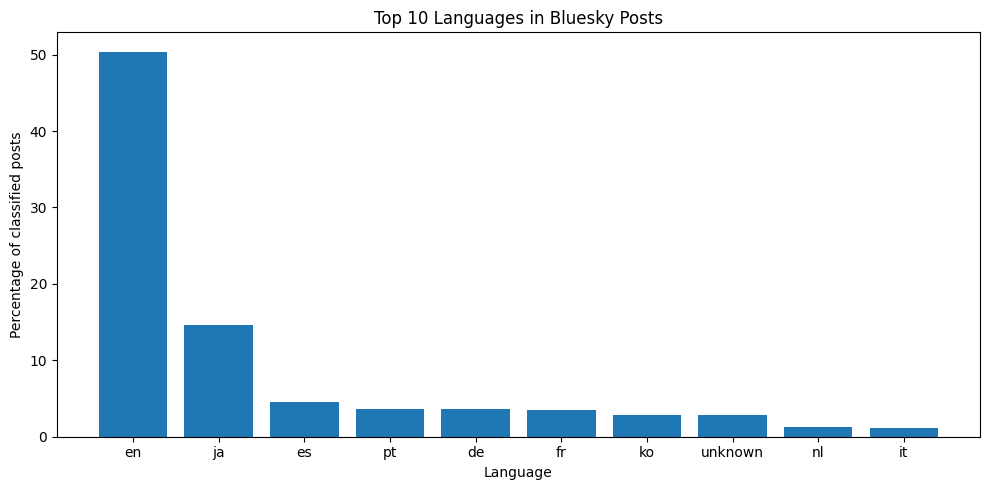

In [ ]:
import matplotlib.pyplot as plt

top_lang = language_summary.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_lang["language"], top_lang["percentage"])
plt.xlabel("Language")
plt.ylabel("Percentage of classified posts")
plt.title("Top 10 Languages in Bluesky Posts")
plt.tight_layout()
plt.show()

## ตอบ ใช้ภาษาอะไร: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

จากการตรวจจับภาษาจากข้อความในโพสต์ พบว่า ภาษาอังกฤษ `English` เป็นภาษาที่พบมากที่สุด คิดเป็นประมาณ `50% `ของโพสต์ทั้งหมด รองลงมาคือ ภาษาญี่ปุ่น `Japanese` ประมาณ 15% และ ภาษาสเปน `Spanish` ประมาณ 5% ส่วนภาษาอื่น ๆ เช่น Portuguese, German, French และ Korean พบในสัดส่วนที่น้อยลงตามลำดับ

จากกราฟสามารถสรุปได้ว่า ภาษาอังกฤษเป็นภาษาหลักของข้อมูลชุดนี้ ดังนั้นหากต้องการทำคอนเทนต์สำหรับกลุ่มผู้ใช้ที่มีลักษณะใกล้เคียงกับข้อมูลนี้ ควร รองรับภาษาอังกฤษเป็นหลัก และอาจเพิ่ม ภาษาญี่ปุ่นและภาษาสเปน เพื่อรองรับกลุ่มผู้ใช้ที่พบในข้อมูลในสัดส่วนรองลงมา

#3.คนพูดถึงอะไร: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

In [ ]:
# ==========================================
# Hashtag ที่พบบ่อย
# ==========================================

from collections import Counter
import re

hashtag_counts = Counter()
hashtag_examples = {}

hashtag_pattern = re.compile(
    r"(?<!\w)#([\w\u0080-\uffff]+)"
)

for file in files:
    for post in iter_jsonl(file):

        text = post.get("text", "")

        hashtags = hashtag_pattern.findall(text)

        for tag in hashtags:

            tag = tag.lower()

            hashtag_counts[tag] += 1

            # เก็บตัวอย่างข้อความจริง
            if tag not in hashtag_examples:
                hashtag_examples[tag] = text


print("\n===== TOP HASHTAGS =====")

for tag, count in hashtag_counts.most_common(15):

    print(
        f"#{tag}: {count}"
    )

    if tag in hashtag_examples:
        print(
            "Example:",
            hashtag_examples[tag][:200]
        )



===== TOP HASHTAGS =====
#art: 727
Example: 100 Artworks From the Top Digital Artists in the USA & Canada – http://bit.ly/Ppfmn Truly #amazing #art!
#booksky: 508
Example: Choose 20 books that have stayed with you or influenced you.
One book per day for 20 days, in no particular order. 

No explanations, no reviews, just covers.
Day 4

💙📚
#booksky
#books
#readingchallen
#nsfw: 415
Example: Mm baby I had a dream where a thousand of your friends came over to look at at my tits. 

And I loved it. ❤️❤️❤️

#milf #milfsky #nsfw #nsfwsky #goonsky #realnsfw #boobsky #boobs #tits #naturaltits #n
#books: 363
Example: Choose 20 books that have stayed with you or influenced you.
One book per day for 20 days, in no particular order. 

No explanations, no reviews, just covers.
Day 4

💙📚
#booksky
#books
#readingchallen
#photography: 351
Example: Short-eared Owl at the Shawangunk Grasslands 🪶 
#owls #birds #wildllifephotography #wildlife #birding #photography #nature
#bastien: 349
Example: L'enfant, 

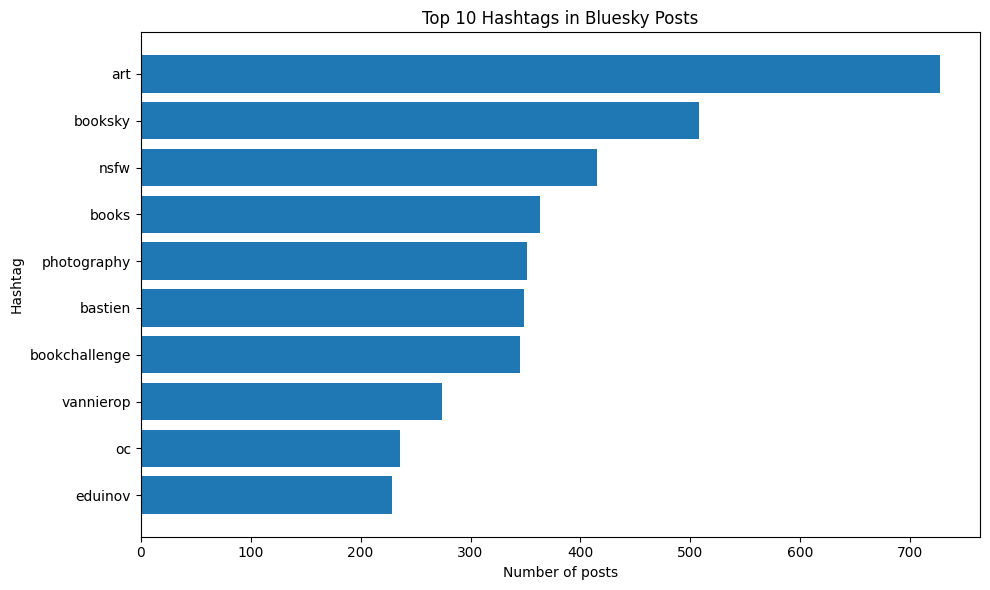

In [ ]:
import pandas as pd

# Create a DataFrame from hashtag_counts
hashtag_df = pd.DataFrame(
    hashtag_counts.most_common(),
    columns=["hashtag", "count"]
)

top_10_hashtags = hashtag_df.head(10).sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_hashtags["hashtag"],
    top_10_hashtags["count"]
)

plt.xlabel("Number of posts")
plt.ylabel("Hashtag")
plt.title("Top 10 Hashtags in Bluesky Posts")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ตัวอย่างข้อความจริง
# ==========================================

print("=" * 100)
print("ตัวอย่างข้อความจริงของ Hashtag ยอดนิยม")
print("=" * 100)

# Define top_hashtags from hashtag_counts
top_hashtags = hashtag_counts.most_common(10)

for tag, count in top_hashtags:

    print(f"\n#{tag}  →  {count} ครั้ง")

    # The hashtag_examples dictionary stores only one example per hashtag.
    # If you want multiple examples, the hashtag_examples dictionary
    # would need to be structured differently (e.g., storing a list of texts).
    example_text = hashtag_examples.get(tag, "No example available.")

    print(f"ตัวอย่าง: {example_text[:500]}")
    print()

ตัวอย่างข้อความจริงของ Hashtag ยอดนิยม

#art  →  727 ครั้ง
ตัวอย่าง: 100 Artworks From the Top Digital Artists in the USA & Canada – http://bit.ly/Ppfmn Truly #amazing #art!


#booksky  →  508 ครั้ง
ตัวอย่าง: Choose 20 books that have stayed with you or influenced you.
One book per day for 20 days, in no particular order. 

No explanations, no reviews, just covers.
Day 4

💙📚
#booksky
#books
#readingchallenge


#nsfw  →  415 ครั้ง
ตัวอย่าง: Mm baby I had a dream where a thousand of your friends came over to look at at my tits. 

And I loved it. ❤️❤️❤️

#milf #milfsky #nsfw #nsfwsky #goonsky #realnsfw #boobsky #boobs #tits #naturaltits #natural #spicysky


#books  →  363 ครั้ง
ตัวอย่าง: Choose 20 books that have stayed with you or influenced you.
One book per day for 20 days, in no particular order. 

No explanations, no reviews, just covers.
Day 4

💙📚
#booksky
#books
#readingchallenge


#photography  →  351 ครั้ง
ตัวอย่าง: Short-eared Owl at the Shawangunk Grasslands 🪶 
#owls #birds #wi

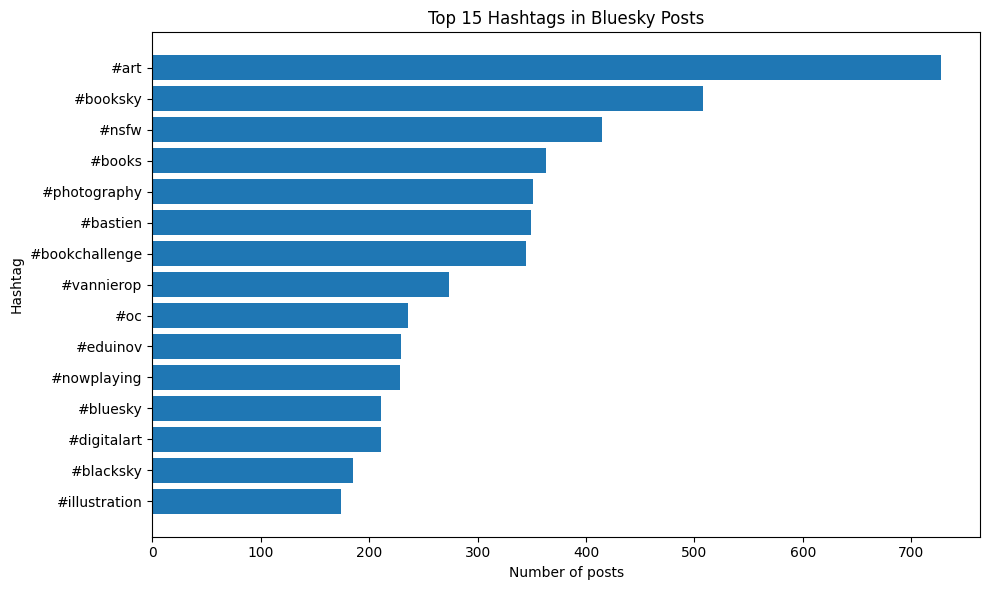

In [ ]:
# ==========================================
# GRAPH 1: TOP HASHTAGS
# ==========================================

plot_df = hashtag_df.head(15).copy()

# ใส่ # ด้านหน้า
plot_df["Hashtag"] = "#" + plot_df["hashtag"]

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Hashtag"][::-1],
    plot_df["count"][::-1]
)

plt.xlabel("Number of posts")
plt.ylabel("Hashtag")

plt.title(
    "Top 15 Hashtags in Bluesky Posts"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# HASHTAG CO-OCCURRENCE
# ==========================================

from itertools import combinations

hashtag_pairs = Counter()

for file in files:

    for post in iter_jsonl(file):

        text = post.get("text", "")

        hashtags = hashtag_pattern.findall(text)

        # ทำให้ไม่ซ้ำภายในโพสต์เดียว
        hashtags = sorted(
            set(tag.lower() for tag in hashtags)
        )

        # สร้างคู่ hashtag
        for pair in combinations(hashtags, 2):

            hashtag_pairs[pair] += 1


top_pairs = hashtag_pairs.most_common(20)

pair_df = pd.DataFrame(
    [
        {
            "Hashtag 1": pair[0],
            "Hashtag 2": pair[1],
            "Count": count
        }
        for pair, count in top_pairs
    ]
)

display(pair_df)

,Hashtag 1,Hashtag 2,Count
0,bookchallenge,booksky,326
1,books,booksky,321
2,bookchallenge,books,269
3,hiring,remotework,126
4,hiring,remotejob,123
5,hiring,wfh,123
6,remotejob,remotework,123
7,remotejob,wfh,123
8,remotework,wfh,123
9,art,digitalart,111


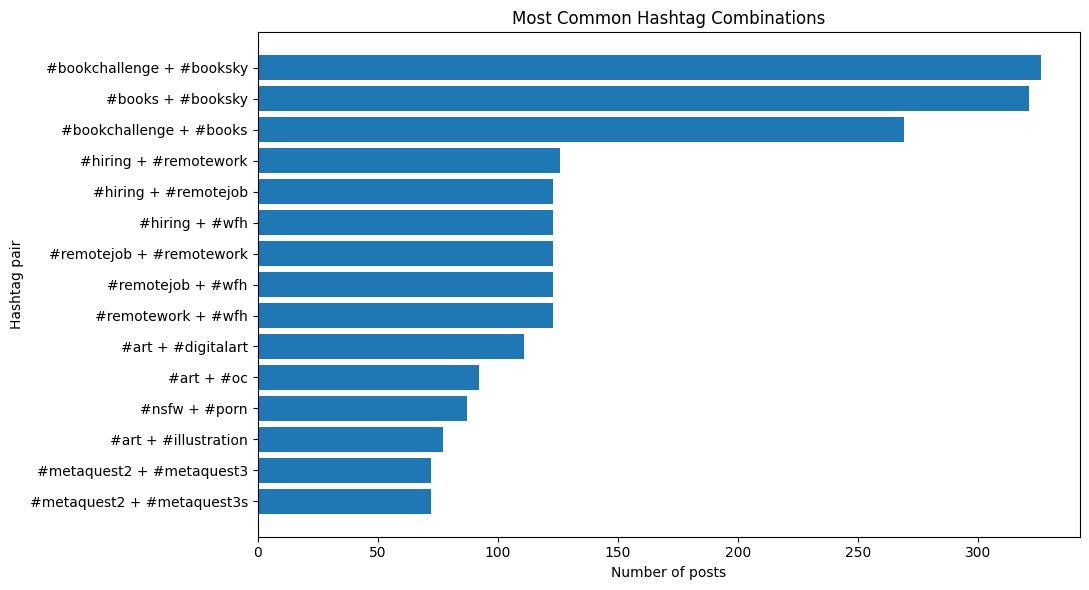

In [ ]:
# ==========================================
# GRAPH 2: HASHTAG PAIRS
# ==========================================

pair_df["Pair"] = (
    "#" + pair_df["Hashtag 1"]
    + " + #"
    + pair_df["Hashtag 2"]
)

plot_df = pair_df.head(15)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_df["Pair"][::-1],
    plot_df["Count"][::-1]
)

plt.xlabel("Number of posts")

plt.ylabel(
    "Hashtag pair"
)

plt.title(
    "Most Common Hashtag Combinations"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# BIGRAM ANALYSIS
# ==========================================

import re
from collections import Counter, defaultdict

# Define clean_text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\S*@\S*\s?', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    text = text.strip()
    return text

# Define stopwords list
stopwords = set([
    "the", "and", "a", "to", "of", "is", "in", "it", "you", "that", "for", "on", "with", "as", "at", "be",
    "this", "was", "i", "have", "but", "not", "are", "my", "your", "me", "so", "do", "just", "what",
    "all", "we", "he", "she", "they", "if", "or", "from", "up", "out", "about", "by", "can", "get",
    "like", "one", "would", "there", "know", "had", "has", "will", "when", "who", "how", "go", "an",
    "am", "no", "yes", "don", "t", "re", "ve", "ll", "s", "m", "d", "their", "which", "them", "our",
    "us", "its", "then", "more", "some", "could", "than", "new", "because", "much", "should", "very",
    "any", "other", "most", "many", "been", "being", "did", "etc", "etcetera", "eg", "ie"
])

bigram_counts = Counter()

bigram_examples = defaultdict(list)


for file in files:

    for post in iter_jsonl(file):

        original_text = post.get("text", "")

        text = clean_text(original_text)

        words = [
            w for w in text.split()
            if len(w) >= 3
            and w not in stopwords
        ]

        # สร้างคู่คำ
        for i in range(len(words) - 1):

            word1 = words[i]
            word2 = words[i + 1]

            bigram = f"{word1} {word2}"

            bigram_counts[bigram] += 1

            if len(bigram_examples[bigram]) < 2:

                bigram_examples[bigram].append(
                    original_text
                )


top_bigrams = bigram_counts.most_common(20)

bigram_df = pd.DataFrame(
    top_bigrams,
    columns=["Phrase", "Count"]
)

display(bigram_df)

,Phrase,Count
0,good morning,2168
1,over under,715
2,right now,560
3,social media,531
4,dont think,526
5,per day,498
6,years ago,496
7,dont want,486
8,particular order,483
9,last night,481


##ตอบ คนพูดถึงอะไร: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ


Hashtag ที่พบ`มากที่สุด`คือ `#art` จำนวน 727 ครั้ง ตัวอย่าง ข้อความพูดถึงผลงานศิลปะและศิลปินดิจิทัล เช่น “100 Artworks From the Top Digital Artists in the USA & Canada” แสดงให้เห็นว่าคอนเทนต์เกี่ยวกับศิลปะเป็นหนึ่งในหัวข้อที่พบได้บ่อย



อีกหัวข้อที่เห็นชัดคือ หนังสือและการอ่าน เช่น `#booksky` พบ 508 ครั้ง และ `#books` พบ 363 ครั้ง โดยมีตัวอย่างโพสต์ที่พูดถึงการเลือกหนังสือ เช่น "Choose 20 books that have stayed with you or influenced you.
One book per day for 20 days, in no particular order." ซึ่งความหมายมีผู้โพสต์ และทำกิจกรรมแนะนำหนังสือวันละเล่ม




วลีที่พบบ่อยที่สุดคือ `good moning` ซึ่งพบมากถึง 2168 ครั้ง รองลงมาคือ over under และ right now

นากจากนี้ยังมี Hashteg ที่มักมาคู่กัน ได้แก่ `#bookchallenge + # booksky` `#books + #booksky`


และยังพบ `#photography` 351 ครั้ง ซึ่งเกี่ยวข้องกับการถ่ายภาพธรรมชาติและสัตว์ เช่น "Short-eared Owl at the Shawangunk Grasslands" ภาพนกฮูกและธรรมชาติ รวมถึง `#nowplaying` 228 ครั้ง ที่ใช้กับโพสต์เกี่ยวกับเพลง


ส่วน hashtag อย่าง `#digitalart` และ `#illustration` สะท้อนว่ามีการพูดถึงงานศิลปะดิจิทัลและภาพประกอบด้วย


ดังนั้น หากมองภาพรวมจาก hashtag ที่พบ เนื้อหาที่เด่นในข้อมูลชุดนี้จะเกี่ยวข้องกับ `งานศิลปะ หนังสือ การถ่ายภาพ ดนตรี และงานสร้างสรรค์ดิจิทัล`

#4.ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้: สร้าง visualization 1 รูป

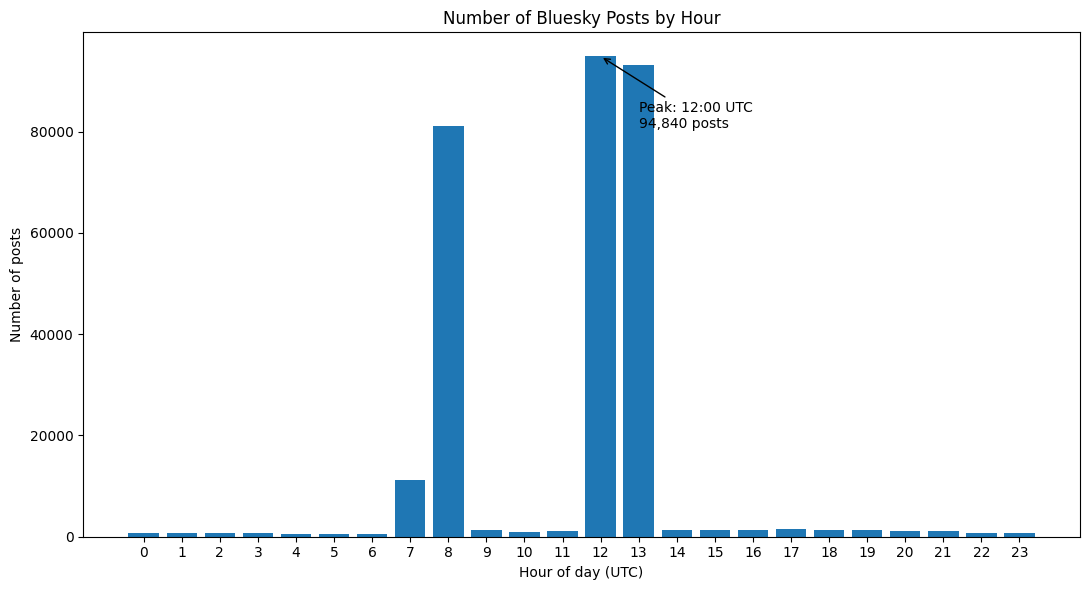

In [ ]:

# ==========================================
# นับจำนวนโพสต์ตามชั่วโมง
# ==========================================

hour_counts = Counter()

total_posts = 0

for file in files:

    for post in iter_jsonl(file):

        total_posts += 1

        dt = datetime.fromisoformat(
            post["created_at"].replace("Z", "+00:00")
        )

        hour_counts[dt.hour] += 1


# ==========================================
# เตรียมข้อมูลสำหรับกราฟ
# ==========================================

hours = list(range(24))

counts = [
    hour_counts[h]
    for h in hours
]


# ==========================================
# หาชั่วโมงที่มีโพสต์มากที่สุด
# ==========================================

peak_hour = max(
    hour_counts,
    key=hour_counts.get
)

peak_count = hour_counts[peak_hour]


# ==========================================
# สร้างกราฟ
# ==========================================

plt.figure(figsize=(11, 6))

plt.bar(
    hours,
    counts
)

plt.xlabel("Hour of day (UTC)")
plt.ylabel("Number of posts")

plt.title(
    "Number of Bluesky Posts by Hour"
)

plt.xticks(hours)

# ใส่คำอธิบายที่จุดสูงสุด
plt.annotate(
    f"Peak: {peak_hour:02d}:00 UTC\n{peak_count:,} posts",
    xy=(peak_hour, peak_count),
    xytext=(peak_hour + 1, peak_count * 0.85),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.show()

## ตอบ ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้: สร้าง visualization 1 รูป

กราฟแท่งแสดงจำนวนโพสต์ในแต่ละชั่วโมง ทำให้เห็นได้ชัดว่า ช่วงเวลา `12:00–13:00 UTC` มีจำนวนโพสต์`สูงมาก`เมื่อเทียบกับช่วงเวลาอื่น โดยเฉพาะเวลา `12:00 UTC ที่มีถึง 94,840 โพสต์`

เนื่องจากข้อมูลที่นำมาวิเคราะห์เป็นเพียงบางส่วนของ dataset และจำนวนโพสต์ในแต่ละช่วงเวลาอาจได้รับผลจากลักษณะของไฟล์ที่เลือกมา นอกจากนี้ยังไม่มีข้อมูล engagement เช่น จำนวน Like, Repost หรือ Reply จึงไม่สามารถบอกได้ว่าโพสต์ช่วงไหนได้รับความสนใจมากที่สุด

### ข้อมูลนี้บอกอะไรได้
►สามารถบอกได้ว่าช่วงเวลาไหนมีการโพสต์มากหรือน้อย ในข้อมูลที่นำมาวิเคราะห์
พบว่าช่วง

► 12:00–13:00 UTC เป็นช่วงที่มีโพสต์หนาแน่นที่สุด

►หากแปลงเป็นเวลาไทย (UTC+7) ช่วงดังกล่าวจะอยู่ประมาณ 19:00–20:00 น.

►กราฟช่วยให้เห็น รูปแบบการกระจายตัวของโพสต์ตามช่วงเวลา ได้ชัดเจน

###ข้อมูลนี้บอกอะไรไม่ได้

►ไม่สามารถสรุปได้ว่า 19:00 น. เป็นเวลาที่ดีที่สุดในการโพสต์ เพราะเรามีเพียงจำนวนโพสต์ ไม่มีข้อมูลยอด Like, Repost หรือ Reply

►ไม่สามารถบอกได้ว่า ผู้ใช้ส่วนใหญ่กำลังออนไลน์อยู่ในช่วงนั้น เพราะจำนวนโพสต์ไม่เท่ากับจำนวนผู้ใช้งาน

►ไม่สามารถนำผลไปแทนพฤติกรรมของผู้ใช้ Bluesky ทั้งหมด ได้ เพราะวิเคราะห์เพียง 300,000 โพสต์จาก dataset

►ไม่สามารถบอกได้ว่า โพสต์ช่วงไหนได้รับความสนใจมากที่สุด เพราะไม่มีข้อมูล engagement

►ช่วงเวลาที่พบมากอาจได้รับอิทธิพลจาก ลักษณะและช่วงเวลาของข้อมูลที่เลือกมา จึงควรใช้เป็นแนวโน้มเบื้องต้นเท่านั้น

###ข้อจำกัดของข้อมูล
► ใช้ข้อมูลเพียง 300,000 โพสต์จาก 1–3 ไฟล์ จึงอาจไม่สะท้อนพฤติกรรมของผู้ใช้ Bluesky ทั้งหมด

► มีข้อมูลจำนวนโพสต์ แต่ไม่มีข้อมูล Like, Repost หรือ Reply จึงไม่สามารถวัดความนิยมของโพสต์ได้

► ช่วงเวลาที่มีโพสต์มาก ไม่ได้หมายความว่าเป็น ช่วงเวลาที่ดีที่สุดในการลงคอนเทนต์
ข้อมูลบางส่วนอาจมีหลายภาษาและข้อความสั้น

► ทำให้การวิเคราะห์ภาษาและหัวข้ออาจเกิดความคลาดเคลื่อนได้
ข้อมูลเป็นเพียงช่วงหนึ่งของเวลา

► จึงไม่ควรนำไปสรุปว่าเป็นพฤติกรรมของผู้ใช้ในปัจจุบันทั้งหมด